# Notebook 06 — Baseline Evaluation (v3)
**Nhóm 67 | Tuần 4 | Ngôn ngữ Lập trình Python**

Notebook này thực hiện đánh giá **Baseline** bằng cách chạy code chuẩn (AC) của **100 bài toán** để xác nhận độ đúng đắn của dữ liệu và hệ thống máy chấm.

In [1]:
import os
import sys
from pathlib import Path

cwd = os.getcwd()
if os.path.basename(cwd) in ['notebookes', 'src', 'data', 'results']:
    BASE = Path(cwd).parent
else:
    BASE = Path(cwd)

sys.path.insert(0, str(BASE / 'src'))
os.chdir(BASE)

import run_baseline
print("✓ Bắt đầu chạy Baseline trên 100 bài toán...\n")
run_baseline.main()

✓ Bắt đầu chạy Baseline trên 100 bài toán...

  CHẠY BASELINE — Code chuẩn trên 50 bài toán
  Dataset: hidden_v2.json  |  Luồng song song: 8

  ✓ Đã load 100 bài toán
  → Mỗi bài: 3 public + 6 hidden tests

  Bắt đầu chạy song song (8 luồng)...

  [✓] Task  6 factorial                      pub=3/3 hid=6/6 lat=0.09s
  [✓] Task  8 remove_duplicates              pub=3/3 hid=6/6 lat=0.0846s
  [✓] Task  4 find_max                       pub=3/3 hid=6/6 lat=0.0902s
  [✓] Task  2 is_even                        pub=3/3 hid=6/6 lat=0.0944s
  [✓] Task  7 is_palindrome                  pub=3/3 hid=6/6 lat=0.0853s
  [✓] Task  3 reverse_string                 pub=3/3 hid=6/6 lat=0.0905s
  [✓] Task  5 count_char                     pub=3/3 hid=6/6 lat=0.097s
  [✓] Task  1 sum_list                       pub=3/3 hid=6/6 lat=0.1016s
  [✓] Task 10 to_uppercase                   pub=3/3 hid=6/6 lat=0.081s
  [✓] Task 12 sum_even                       pub=3/3 hid=6/6 lat=0.0876s
  [✓] Task  9 average       

In [ ]:
import pandas as pd
df_bl = pd.read_csv(BASE / 'results' / 'baseline_summary.csv')

print(f"Số bài toán: {len(df_bl)}")
print(f"Baseline OK (pass 100%): {df_bl['baseline_ok'].sum()}/{len(df_bl)}")
print(f"Latency public trung bình : {df_bl['pub_latency'].mean():.4f}s/test")
print(f"Latency hidden trung bình  : {df_bl['hid_latency'].mean():.4f}s/test")
print(f"Latency tổng trung bình    : {df_bl['avg_latency_total'].mean():.4f}s/test\n")

print("Mẫu bảng kết quả baseline (10 dòng đầu):")
display(df_bl[['task_id', 'func_name', 'topic', 'pub_pass', 'pub_total', 'hid_pass', 'hid_total', 'baseline_ok', 'avg_latency_total']].head(10))

---
## So sánh Latency theo các bộ test (Set 1 → Set 4)

Phân tích thời gian chấm bài thực tế trên **50 submissions** với 4 cấu hình:
- **Set 1** — 3 public tests
- **Set 2** — 3 public + 6 hidden = 9 tests
- **Set 3** — 3 public + 6–10 hidden = 13 tests (Full-run)
- **Set 4** — Set 3 + **Fail-Fast** (dừng sớm khi gặp lỗi đầu tiên)


  SO SÁNH LATENCY THEO CÁC BỘ TEST CASES (50 submissions)
       Bộ test  TB/test (ms)  TB/submission (ms)  P95/submission (ms)  Tổng 50 bài nộp (s)
    Set 1 (3t)         51.14              155.70               197.87              15.5696
    Set 2 (9t)         46.69              424.28               535.51              42.4283
   Set 3 (13t)         45.71              467.67               701.05              46.7670
Set 4 (13t+FF)         45.30              100.98               367.33              10.0976

  ✓ Fail-Fast (Set 4) nhanh hơn Full-run (Set 3):
     • Tổng thời gian chấm : 4.63x  (46.767s → 10.098s)
     • Độ trễ P95/bài nộp : 1.91x  (701.0ms → 367.3ms)



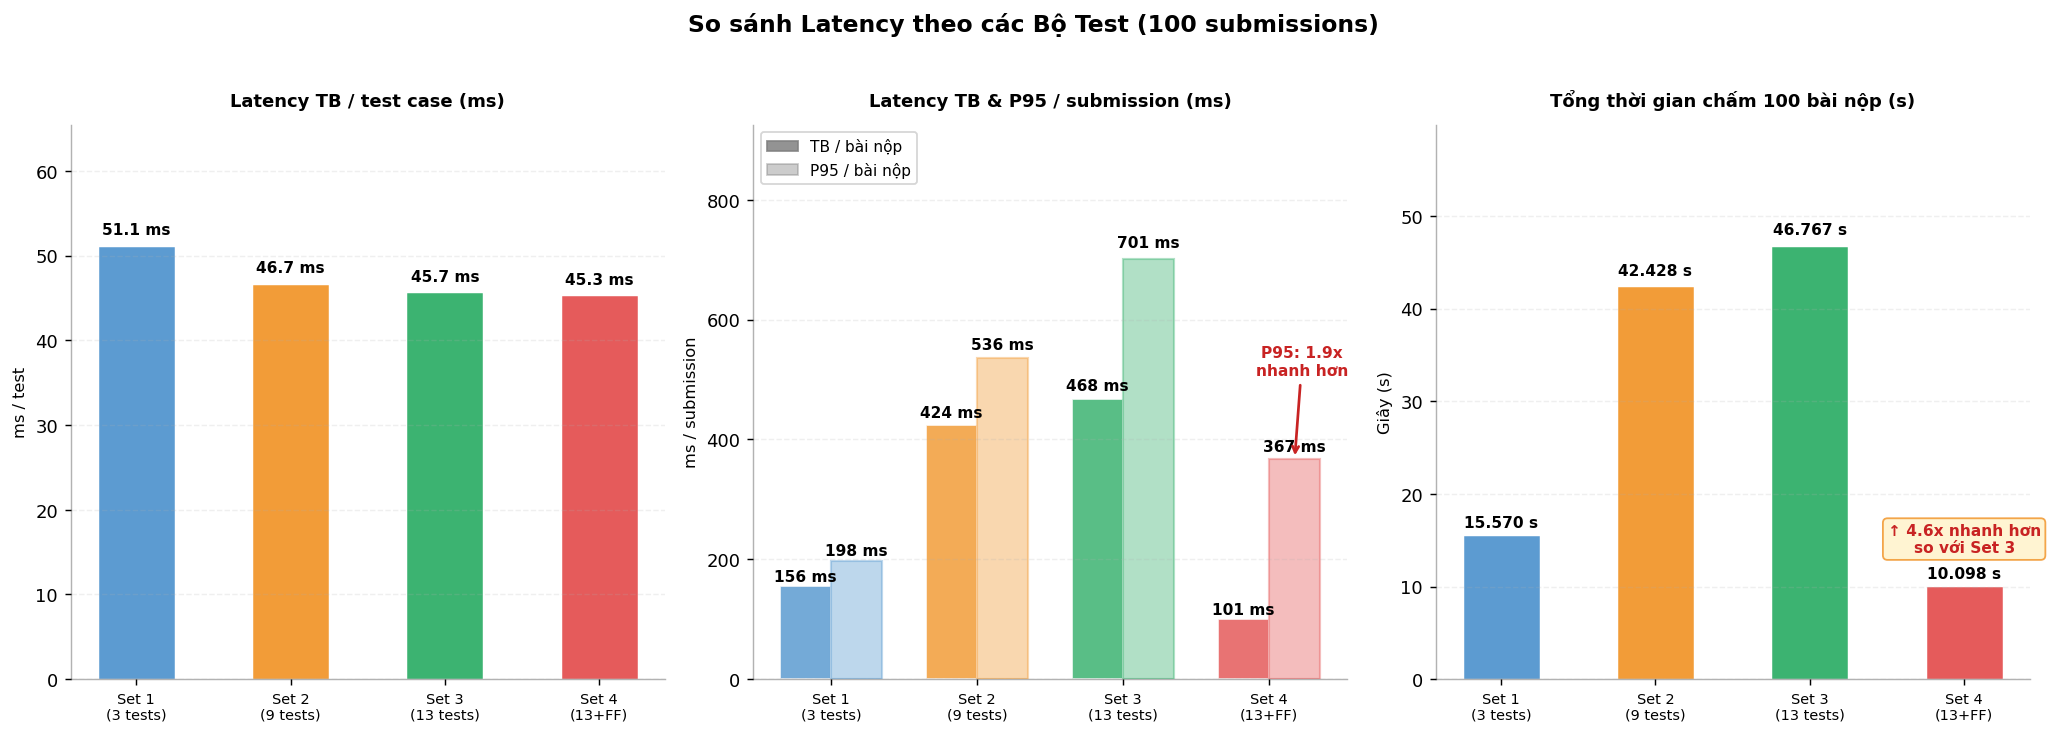

✓ Đã lưu biểu đồ: e:\Bao Cao Ha Dung\Tuan4-test\Project\results\baseline_latency_sets.png


In [2]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── 1. Resolve BASE path ────────────────────────────────────────────────────
cwd = os.getcwd()
if os.path.basename(cwd) in ['notebookes', 'src', 'data', 'results']:
    BASE = Path(cwd).parent
else:
    BASE = Path(cwd)

# ── 2. Load comparison_week4.json ──────────────────────────────────────────
comp_path = BASE / 'results' / 'comparison_week4.json'
with open(comp_path, encoding='utf-8') as f:
    comp = json.load(f)
stats = comp['stats']

SETS   = ['Set 1\n(3 tests)', 'Set 2\n(9 tests)', 'Set 3\n(13 tests)', 'Set 4\n(13+FF)']
KEYS   = ['set1', 'set2', 'set3', 'set4']
COLORS = ['#5C9BD1', '#F29C38', '#3CB371', '#E55B5B']

avg_test = [stats[k]['avg_latency_test_ms']  for k in KEYS]
avg_sub  = [stats[k]['avg_latency_sub_ms']   for k in KEYS]
p95_sub  = [stats[k]['p95_latency_sub_ms']   for k in KEYS]
total_s  = [stats[k]['total_latency_sub_s']  for k in KEYS]

# ── 3. Bảng tóm tắt ────────────────────────────────────────────────────────
df_lat = pd.DataFrame({
    'Bộ test'             : ['Set 1 (3t)', 'Set 2 (9t)', 'Set 3 (13t)', 'Set 4 (13t+FF)'],
    'TB/test (ms)'        : avg_test,
    'TB/submission (ms)'  : avg_sub,
    'P95/submission (ms)' : p95_sub,
    'Tổng 50 bài nộp (s)' : total_s,
})
print('=' * 72)
print('  SO SÁNH LATENCY THEO CÁC BỘ TEST CASES (50 submissions)')
print('=' * 72)
print(df_lat.to_string(index=False))

speedup_total = total_s[2] / total_s[3]
speedup_p95   = p95_sub[2]  / p95_sub[3]
print(f"""
  ✓ Fail-Fast (Set 4) nhanh hơn Full-run (Set 3):
     • Tổng thời gian chấm : {speedup_total:.2f}x  ({total_s[2]:.3f}s → {total_s[3]:.3f}s)
     • Độ trễ P95/bài nộp : {speedup_p95:.2f}x  ({p95_sub[2]:.1f}ms → {p95_sub[3]:.1f}ms)
""")

# ── 4. Vẽ 3 biểu đồ ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), dpi=130)
fig.suptitle('So sánh Latency theo các Bộ Test (100 submissions)',
             fontsize=13, fontweight='bold', y=1.02)

def style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.3)
    ax.spines['bottom'].set_alpha(0.3)
    ax.grid(axis='y', alpha=0.2, linestyle='--')

def add_bar_labels(ax, bars, fmt='{:.1f}', suffix=''):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + max(h * 0.02, 0.5),
                fmt.format(h) + suffix,
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ── Subplot 1: TB latency / test (ms) ──────────────────────────────────────
ax1 = axes[0]
b1 = ax1.bar(SETS, avg_test, color=COLORS, width=0.5, edgecolor='white', linewidth=0.8)
add_bar_labels(ax1, b1, fmt='{:.1f}', suffix=' ms')
ax1.set_title('Latency TB / test case (ms)', fontsize=10, fontweight='bold', pad=10)
ax1.set_ylabel('ms / test', fontsize=9)
ax1.set_ylim(0, max(avg_test) * 1.28)
ax1.tick_params(axis='x', labelsize=8)
style(ax1)

# ── Subplot 2: TB & P95 latency / submission (ms) ──────────────────────────
ax2 = axes[1]
x = np.arange(len(SETS))
w = 0.35
b_avg = ax2.bar(x - w / 2, avg_sub, w, color=COLORS, alpha=0.85, edgecolor='white')
b_p95 = ax2.bar(x + w / 2, p95_sub, w, color=COLORS, alpha=0.40,
                edgecolor=[c for c in COLORS], linewidth=1.2)
add_bar_labels(ax2, b_avg, fmt='{:.0f}', suffix=' ms')
add_bar_labels(ax2, b_p95, fmt='{:.0f}', suffix=' ms')
ax2.set_title('Latency TB & P95 / submission (ms)', fontsize=10, fontweight='bold', pad=10)
ax2.set_ylabel('ms / submission', fontsize=9)
ax2.set_ylim(0, max(p95_sub) * 1.32)
ax2.set_xticks(x)
ax2.set_xticklabels(SETS, fontsize=8)
ax2.annotate(
    f'P95: {speedup_p95:.1f}x\nnhanh hơn',
    xy=(x[3] + w / 2, p95_sub[3]),
    xytext=(x[3] + w / 2 + 0.05, p95_sub[3] + max(p95_sub) * 0.20),
    arrowprops=dict(arrowstyle='->', color='#C82323', lw=1.5),
    fontsize=8.5, color='#C82323', fontweight='bold', ha='center'
)
avg_patch = mpatches.Patch(color='grey', alpha=0.85, label='TB / bài nộp')
p95_patch = mpatches.Patch(color='grey', alpha=0.40, label='P95 / bài nộp')
ax2.legend(handles=[avg_patch, p95_patch], fontsize=8.5, loc='upper left')
style(ax2)

# ── Subplot 3: Tổng thời gian chấm 100 submissions (s) ──────────────────────
ax3 = axes[2]
b3 = ax3.bar(SETS, total_s, color=COLORS, width=0.5, edgecolor='white', linewidth=0.8)
add_bar_labels(ax3, b3, fmt='{:.3f}', suffix=' s')
ax3.set_title('Tổng thời gian chấm 100 bài nộp (s)', fontsize=10, fontweight='bold', pad=10)
ax3.set_ylabel('Giây (s)', fontsize=9)
ax3.set_ylim(0, max(total_s) * 1.28)
ax3.tick_params(axis='x', labelsize=8)
ax3.text(3, total_s[3] + max(total_s) * 0.07,
         f'↑ {speedup_total:.1f}x nhanh hơn\nso với Set 3',
         ha='center', va='bottom', fontsize=8.5, color='#C82323', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD',
                   alpha=0.9, edgecolor='#F29C38'))
style(ax3)

plt.tight_layout()
out_path = BASE / 'results' / 'baseline_latency_sets.png'
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'✓ Đã lưu biểu đồ: {out_path}')
